# Multiclass Classification, Softmax, and Activation Functions

In this notebook, I will explore how neural networks handle multiclass classification.

The focus is on:

- binary vs multiclass classification
- softmax activation
- logits
- sparse categorical cross-entropy
- choosing output layer activations
- sigmoid, ReLU, linear, and softmax activations

This notebook uses TensorFlow/Keras for training, but I will also implement the softmax function manually using NumPy to understand the idea behind it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

## 1. Binary vs Multiclass Classification

In binary classification, the model predicts between two classes:

$$
y \in \{0, 1\}
$$

The output layer usually has one neuron with sigmoid activation.

In multiclass classification, the model predicts between more than two classes:

$$
y \in \{0, 1, 2, ..., K-1\}
$$

For multiclass classification, the model outputs one score for each class.

## 2. Creating a Simple Multiclass Dataset

To keep the notebook simple, I will create a toy dataset with three classes.

Each example has two features:

$$
x_1, x_2
$$

The label can be one of three classes:

$$
y \in \{0, 1, 2\}
$$

In [3]:
m_per_class = 100

# Class 0
X0 = np.random.randn(m_per_class, 2) + np.array([-2, 0])
y0 = np.zeros(m_per_class)

# Class 1
X1 = np.random.randn(m_per_class, 2) + np.array([2, 0])
y1 = np.ones(m_per_class)

# Class 2
X2 = np.random.randn(m_per_class, 2) + np.array([0, 3])
y2 = np.full(m_per_class, 2)

X = np.vstack([X0, X1, X2])
y = np.concatenate([y0, y1, y2]).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

X shape: (300, 2)
y shape: (300,)
Classes: [0 1 2]


### Dataset Shape

The dataset has 300 examples and 2 input features.

There are 3 classes:

- Class 0
- Class 1
- Class 2

This makes it a simple multiclass classification problem.

In [4]:
m = X.shape[0]

indices = np.random.permutation(m)

X = X[indices]
y = y[indices]

print("First 10 labels:", y[:10])

First 10 labels: [0 0 2 1 0 0 2 0 0 1]


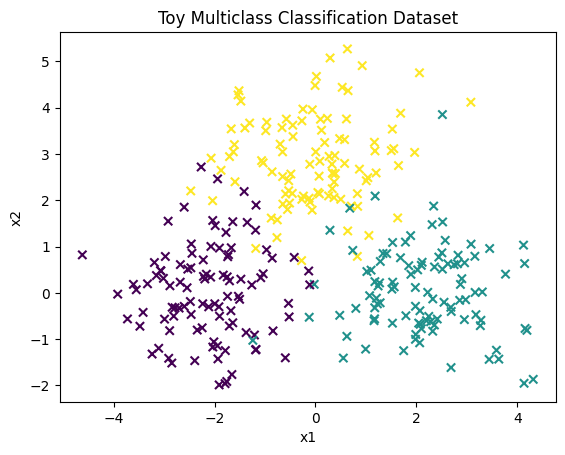

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y, marker="x")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Toy Multiclass Classification Dataset")
plt.show()

### Dataset Visualization

The plot shows three groups of points.

The goal of the neural network is to learn decision boundaries that separate these three classes.

## 2.1 Train/Test Split

I will split the dataset into training and test sets.

The training set is used to fit the model, while the test set is used to evaluate how well the model performs on unseen data.

In [6]:
split = int(0.8 * m)

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (240, 2)
y_train shape: (240,)
X_test shape: (60, 2)
y_test shape: (60,)


In [7]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

print("Mean:", mu.round(3))
print("Standard deviation:", sigma.round(3))

Mean: [-0.115  1.003]
Standard deviation: [1.941 1.657]


### Why Normalize Features?

Neural networks usually train better when input features are on a similar scale.

Here, I use z-score normalization:

$$
x_{norm} = \frac{x - \mu}{\sigma}
$$

The mean and standard deviation are calculated from the training set only, then applied to both the training and test sets.

## 3. Softmax Function

For multiclass classification, the model produces one score for each class.

These raw scores are called logits.

The softmax function converts logits into probabilities:

$$
a_j = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}
$$

Each output is between 0 and 1, and all class probabilities add up to 1.

In [8]:
def softmax(z):
    """
    Compute softmax values for a vector of logits.

    Args:
        z: ndarray of shape (n_classes,)

    Returns:
        probabilities: ndarray of shape (n_classes,)
    """
    z_stable = z - np.max(z)
    exp_z = np.exp(z_stable)
    probabilities = exp_z / np.sum(exp_z)

    return probabilities

In [9]:
logits_example = np.array([2.0, 1.0, 0.1])

probs = softmax(logits_example)

print("Logits:", logits_example)
print("Probabilities:", probs)
print("Sum of probabilities:", np.sum(probs))
print("Predicted class:", np.argmax(probs))

Logits: [2.  1.  0.1]
Probabilities: [0.65900114 0.24243297 0.09856589]
Sum of probabilities: 1.0
Predicted class: 0


### Softmax Output Interpretation

The softmax function converts raw logits into probabilities.

The probabilities add up to 1, and the predicted class is the class with the highest probability.

This is why `np.argmax()` is used later to convert probability vectors into class predictions.

## 4. Building a Multiclass Neural Network

For a multiclass classification problem with 3 classes, the output layer should have 3 units.

Each output unit corresponds to one class.

For this notebook, I will use a linear output layer and let TensorFlow's loss function handle the softmax calculation internally.

This is done using:

```python
SparseCategoricalCrossentropy(from_logits=True)
```

This approach is numerically more stable than manually applying softmax in the output layer during training.

In [10]:
model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(3, activation="linear")
    ],
    name ="multiclass_classification_model"
)

In [11]:
model.summary()

Model: "multiclass_classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211 (844.00 B)

 Trainable params: 211 (844.00 B)

 Non-trainable params: 0 (0.00 B)

### Model Architecture Explanation

The model has two hidden layers with ReLU activation.

The output layer has 3 units because there are 3 classes.

The output activation is linear because the model outputs logits. These logits will be passed directly into the loss function.

## 5. Compiling the Model

Because this is a multiclass classification problem, I will use sparse categorical cross-entropy.

Since the output layer gives raw logits, I will set:

```python
from_logits=True
```

This tells TensorFlow that the model output has not passed through softmax yet.

In [ ]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]    
)

In [13]:
history = model.fit(
    X_train_norm,
    y_train,
    epochs=100,
    verbose=0
)

### Training Process

During training, TensorFlow repeatedly performs:

1. Forward propagation
2. Loss calculation
3. Backpropagation
4. Parameter updates

The details of backpropagation are handled automatically here. I will explore backpropagation from scratch in a separate notebook.

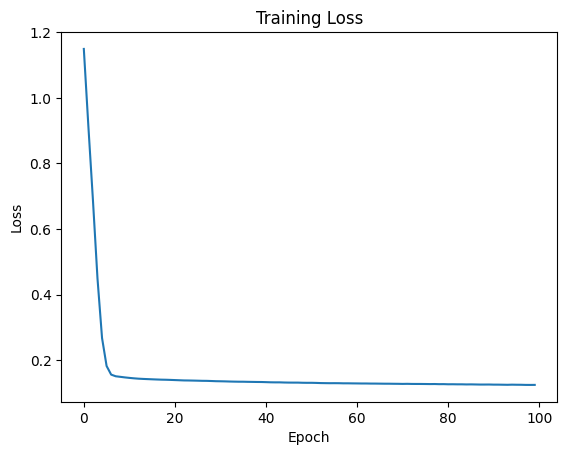

In [14]:
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

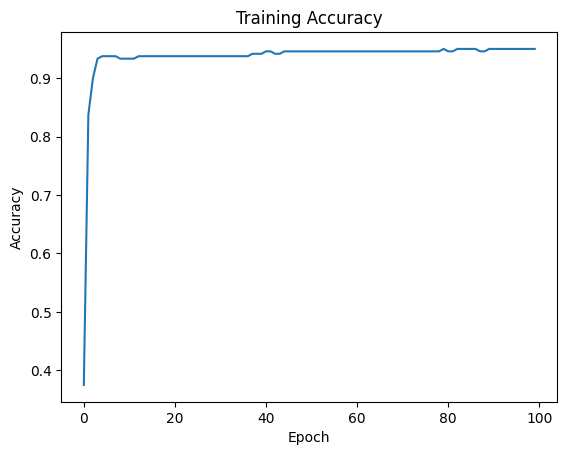

In [15]:
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

In [16]:
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.14587998390197754
Test accuracy: 0.9333333373069763


### Test Set Evaluation

The test accuracy shows how well the model performs on data it did not see during training.

Since this is a simple toy dataset, the model should achieve reasonably high accuracy if the classes are separable.

## 6. Making Predictions with Logits

Since the model's output layer is linear, the raw output values are logits.

To convert logits into probabilities, I will apply softmax.

### Prediction Workflow

The prediction process follows this sequence:

```text
input features → model logits → softmax probabilities → predicted class
```

The final predicted class is chosen using the index of the largest probability.

In [17]:
logits = model.predict(X_test_norm, verbose=0)

print("First 5 logits:")
print(logits[:5])

First 5 logits:
[[-5.634161    5.105409    1.4773877 ]
 [-9.827807    8.00408    -0.51650167]
 [-2.957349    1.7678236   6.380817  ]
 [ 1.4701561   4.82126    -0.15162882]
 [ 8.109874    2.9447722  -0.7274951 ]]


In [18]:
probabilities = tf.nn.softmax(logits).numpy()

print("First 5 probability vectors:")
print(probabilities[:5])

print("\nSum of first probability vector:")
print(np.sum(probabilities[0]))

First 5 probability vectors:
[[2.1108946e-05 9.7409838e-01 2.5880525e-02]
 [1.8014559e-08 9.9980074e-01 1.9928381e-04]
 [8.7128501e-05 9.8237395e-03 9.9008918e-01]
 [3.3634063e-02 9.5972162e-01 6.6442662e-03]
 [9.9417639e-01 5.6792162e-03 1.4435867e-04]]

Sum of first probability vector:
1.0


In [19]:
y_pred = np.argmax(probabilities, axis=1)

print("First 10 predicted labels:")
print(y_pred[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

First 10 predicted labels:
[1 1 2 1 0 0 2 1 2 1]

First 10 actual labels:
[1 1 2 1 0 0 1 2 2 1]


In [20]:
manual_accuracy = np.mean(y_pred == y_test)

print("Manual test accuracy:", manual_accuracy)

Manual test accuracy: 0.9333333333333333


## 7. Activation Functions

Activation functions allow neural networks to learn non-linear patterns.

Without non-linear activation functions, a neural network would behave like a linear model even if it had multiple layers.

Common activation functions include:

- sigmoid
- ReLU
- linear
- softmax

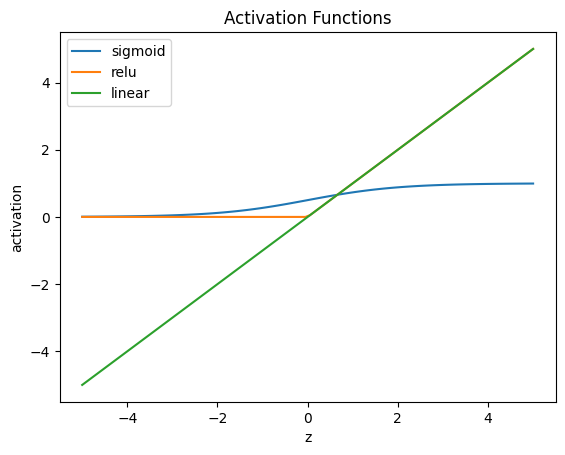

In [21]:
z = np.linspace(-5, 5, 100)

sigmoid = 1 / (1 + np.exp(-z))
relu = np.maximum(0, z)
linear = z

plt.plot(z, sigmoid, label="sigmoid")
plt.plot(z, relu, label="relu")
plt.plot(z, linear, label="linear")
plt.xlabel("z")
plt.ylabel("activation")
plt.title("Activation Functions")
plt.legend()
plt.show()

## 8. Choosing Output Layer Activations

The output layer depends on the type of problem.

| Problem Type | Output Units | Output Activation | Loss Function |
| --- | --- | --- | --- |
| Binary classification | 1 | Sigmoid | Binary cross-entropy |
| Multiclass classification | Number of classes | Linear logits or Softmax | Sparse categorical cross-entropy |
| Regression | 1 | Linear | Mean squared error |

For multiclass classification, using a linear output layer with:

```python
SparseCategoricalCrossentropy(from_logits=True)
```

is preferred because TensorFlow can compute softmax and cross-entropy together in a more numerically stable way.

## 9. Key Takeaways

In this notebook, I explored multiclass classification and activation functions.

The main ideas were:

1. Binary classification predicts between two classes.
2. Multiclass classification predicts between more than two classes.
3. Softmax converts logits into class probabilities.
4. The predicted class is the class with the highest probability.
5. ReLU is commonly used in hidden layers.
6. Sigmoid is commonly used for binary classification output layers.
7. Linear output layers are used for regression and also for multiclass logits.
8. In TensorFlow, `SparseCategoricalCrossentropy(from_logits=True)` is preferred when the model outputs logits.

This notebook focused on how to design neural network outputs correctly for classification problems.

Backpropagation will be explored separately from scratch in the next notebook.